**Я взял датасет картинок разных музыкальных инструментов и сделал классификацию с помощью ResNet**

In [ ]:
import pandas as pd
import numpy as np
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet18_Weights
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from PIL import Image

In [ ]:
!pip install kaggle

import os
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d gpiosenka/musical-instruments-image-classification --unzip -p ./data

In [ ]:
df = pd.read_csv("/content/data/instruments.csv")
df.head(2)

,filepaths,labels,data set
0,train/acordian/001.jpg,acordian,train
1,train/acordian/002.jpg,acordian,train


In [ ]:
df['filepaths'] = '/content/data/' + df['filepaths']

In [ ]:
paths = df['filepaths'].tolist()
labels = df['labels'].tolist()
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

In [ ]:
train_indices = np.where(df['data set'] == 'train')[0]
test_indices = np.where(df['data set'] == 'test')[0]
val_indices = np.where(df['data set'] == 'valid')[0]

In [ ]:
train_paths = [paths[i] for i in train_indices]
train_labels = [encoded_labels[i] for i in train_indices]

val_paths = [paths[i] for i in val_indices]
val_labels = [encoded_labels[i] for i in val_indices]

test_paths = [paths[i] for i in test_indices]
test_labels = [encoded_labels[i] for i in test_indices]

In [ ]:
class InstrumentDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
        return image, label


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = InstrumentDataset(train_paths, train_labels, transform=transform)
val_dataset = InstrumentDataset(val_paths, val_labels, transform=transform)
test_dataset = InstrumentDataset(test_paths, test_labels, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [ ]:
# ResNet18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in list(model.parameters())[:-15]:
            param.requires_grad = False
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(label_encoder.classes_))
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, val_accuracies, label='Val Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

Epoch 1/10, Train Loss: 0.5112, Train Acc: 86.13%, Val Loss: 0.0862, Val Acc: 98.00%
Epoch 2/10, Train Loss: 0.1182, Train Acc: 96.89%, Val Loss: 0.1031, Val Acc: 96.67%
Epoch 3/10, Train Loss: 0.0582, Train Acc: 98.39%, Val Loss: 0.0184, Val Acc: 99.33%
Epoch 4/10, Train Loss: 0.0419, Train Acc: 98.87%, Val Loss: 0.0104, Val Acc: 100.00%
Epoch 5/10, Train Loss: 0.0260, Train Acc: 99.29%, Val Loss: 0.0028, Val Acc: 100.00%
Epoch 6/10, Train Loss: 0.0359, Train Acc: 99.04%, Val Loss: 0.0334, Val Acc: 99.33%
Epoch 7/10, Train Loss: 0.0554, Train Acc: 98.12%, Val Loss: 0.0242, Val Acc: 98.67%
Epoch 8/10, Train Loss: 0.0592, Train Acc: 98.33%, Val Loss: 0.0143, Val Acc: 98.67%
Epoch 9/10, Train Loss: 0.0304, Train Acc: 99.14%, Val Loss: 0.0010, Val Acc: 100.00%
Epoch 10/10, Train Loss: 0.0126, Train Acc: 99.73%, Val Loss: 0.0005, Val Acc: 100.00%


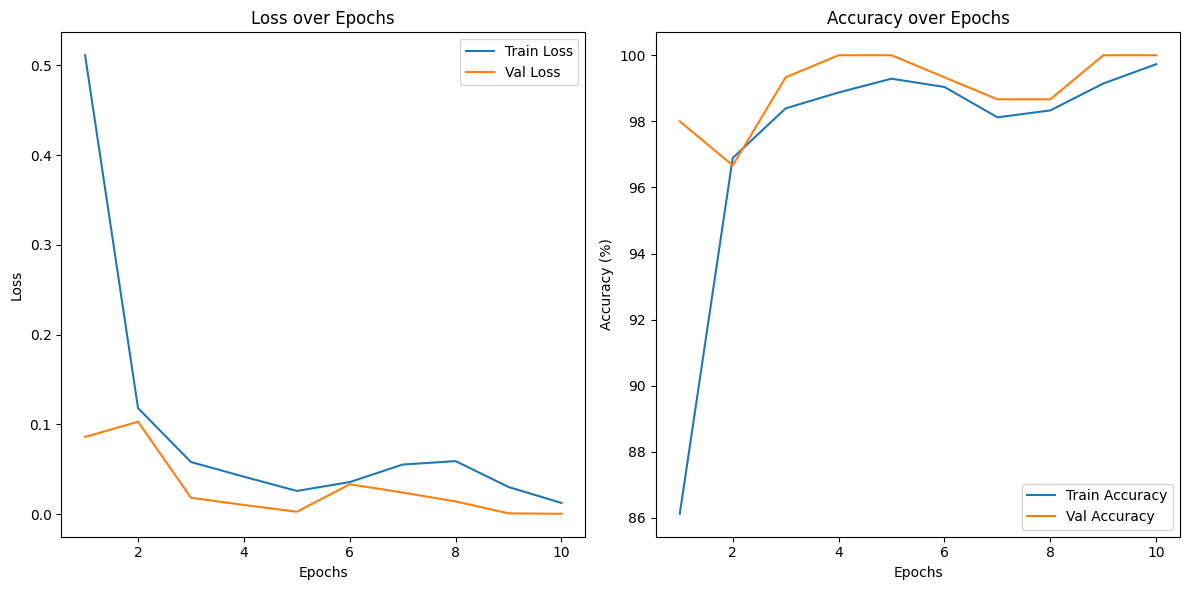

In [ ]:
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

In [ ]:
from sklearn.metrics import classification_report

def evaluate_model(model, test_loader, label_encoder):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))
evaluate_model(model, test_loader, label_encoder)

              precision    recall  f1-score   support

  Didgeridoo       1.00      1.00      1.00         5
  Tambourine       1.00      1.00      1.00         5
   Xylophone       1.00      1.00      1.00         5
    acordian       1.00      1.00      1.00         5
     alphorn       1.00      1.00      1.00         5
    bagpipes       1.00      1.00      1.00         5
       banjo       1.00      1.00      1.00         5
  bongo drum       1.00      1.00      1.00         5
      casaba       1.00      1.00      1.00         5
   castanets       1.00      1.00      1.00         5
    clarinet       0.83      1.00      0.91         5
  clavichord       1.00      1.00      1.00         5
  concertina       1.00      1.00      1.00         5
       drums       1.00      1.00      1.00         5
    dulcimer       1.00      1.00      1.00         5
       flute       1.00      0.80      0.89         5
       guiro       1.00      1.00      1.00         5
      guitar       1.00    

В начале я использовал модель из keras TenserFlow и метрики были очень плохие, поменяв на Pytorch все стало хорошо